# Constraint Satisfaction Problem

Emil Schläger, Mat-Nr: X, infX@lehre.dhbw-stuttgart.de

Maxim Tausch, Mat-Nr: 8395214, inf23142@lehre.dhbw-stuttgart.de

## Aufgabe: 
### Labor- und Präsentationsplanung als Constraint Satisfaction Problem (CSP)


In [391]:
%pip install python-constraint ortools pandas jinja2 matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### CSP-Konfiguration laden und darstellen

Tragen Sie den Namen des Konfigurationsfiles ein. Dieses wird kurz analysiert und dargestellt. Danach können Sie es geeignet dem CSP übergeben.


In [392]:
# Ihr Dateiname - nacheinander mehrere Konfigurationen testen und analysieren.
from csp_utils import analyze_and_display
config_file = "configA.json"
analyze_and_display(config_file)


# CSP-Konfiguration

Verwendete Datei: /Users/maximtausch/Documents/Studium/6. Semester/Grundlagen der KI/Reichhardt/C1/configA.json
Lademodus: json


## Übersicht

Gruppen:
  G1, G2, G3, G4, G5
Tage:
  Mon, Tue, Wed, Thu, Fri
Zeitslots:
  1: 08:00–10:00
  2: 10:30–12:30
  3: 13:00–14:30
  4: 15:00–17:00
Räume:
  L1, L2, L3
Anzahl Kommissionen:
  5
Anzahl Verfügbarkeits-Einträge:
  100


## Kompetenzen der Kommissionen

...

## Legende

Kommission,Farbe
K1,
K2,
K3,
K4,
K5,


## Wochenplan der Verfügbarkeiten

,Mon,Tue,Wed,Thu,Fri
Zeitslot,,,,,
1 (08:00–10:00),"K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5"
2 (10:30–12:30),"K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5"
3 (13:00–14:30),"K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5"
4 (15:00–17:00),"K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5","K1, K2, K3, K4, K5"


{'groups': ['G1', 'G2', 'G3', 'G4', 'G5'],
 'days': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'],
 'timeslots': {'1': '08:00–10:00',
  '2': '10:30–12:30',
  '3': '13:00–14:30',
  '4': '15:00–17:00'},
 'rooms': ['L1', 'L2', 'L3'],
 'commissions': {'K1': ['A', 'B'],
  'K2': ['B', 'C'],
  'K3': ['A'],
  'K4': ['A', 'B'],
  'K5': ['A', 'C']},
 'availability': {'K1': [['Mon', 1],
   ['Mon', 2],
   ['Mon', 3],
   ['Mon', 4],
   ['Tue', 1],
   ['Tue', 2],
   ['Tue', 3],
   ['Tue', 4],
   ['Wed', 1],
   ['Wed', 2],
   ['Wed', 3],
   ['Wed', 4],
   ['Thu', 1],
   ['Thu', 2],
   ['Thu', 3],
   ['Thu', 4],
   ['Fri', 1],
   ['Fri', 2],
   ['Fri', 3],
   ['Fri', 4]],
  'K2': [['Mon', 1],
   ['Mon', 2],
   ['Mon', 3],
   ['Mon', 4],
   ['Tue', 1],
   ['Tue', 2],
   ['Tue', 3],
   ['Tue', 4],
   ['Wed', 1],
   ['Wed', 2],
   ['Wed', 3],
   ['Wed', 4],
   ['Thu', 1],
   ['Thu', 2],
   ['Thu', 3],
   ['Thu', 4],
   ['Fri', 1],
   ['Fri', 2],
   ['Fri', 3],
   ['Fri', 4]],
  'K3': [['Mon', 1],
   ['Mon', 2],
  

## Definition des Constraint Problems

Sie können die Bibliothek aus der Vorlesung nutzen, aber auch andere, z.B. diese:

| Bibliothek            | Vorteile |
|----------------------|---------|
| python-constraint    | Sehr einfach zu nutzen, ideal für klassische CSPs, perfekt für einfache Einführungsaufgaben |
| Google OR-Tools      | Sehr leistungsfähig, unterstützt komplexe Optimierung und Scheduling, industrieller Standard |
| Pyomo                | Saubere mathematische Modellierung, gut für lineare und ganzzahlige Optimierung |
| MiniZinc             | Speziell für Constraint-Probleme entwickelt, klare und strukturierte Modellierung |

### Schritt 1: Modellierungsentscheidung

**Konfiguration:**
- **Domäne:** Jede Präsentation kann jedem gültigen Slot zugeordnet werden (Tag, Timeslot $\in$ {1,2,3,4}, Kommission, Raum).
- **Constraint-Typ:** Mix aus unären (Raum/Kommission-Zulässigkeit) und binären (keine Doppelbelegung) sowie globalen Constraints (Gruppenregeln A $\rightarrow$ B $\rightarrow$ C).
- **python-constraint** Einfach zu nutzen, eignet sich für klassische CSPs, ideal zur schnellen Prototypisierung und zum Verständnis.

Die Konfiguration `configC.json` hatte ein Duplikat der Gruppe `G9`. Damit der CSP-Algorithmus dennoch angewendet werden kann, wurde das Duplikat aus der Konfiguration gelöscht.

In [393]:
from constraint import Problem
from itertools import combinations
import json

with open(config_file, "r") as f:
    config = json.load(f)

len_days = len(config["days"])

len_timeslots = len(config["timeslots"])

DAYS_TO_INT = {"Mon": 0, "Tue": 1, "Wed": 2, "Thu": 3, "Fri": 4}


PRESENTATION_ROOMS = {"A": ["L1", "L2"], "B": ["L3"], "C": ["L1", "L2", "L3"]}


# The two hardest things in programming are naming things, cache invalidation and off-by-one errors.
dhbw = Problem()

# domain for the variable: The details for the slot a presentation is held in
slot_domains = [
    (day, slot, commission, room)
    for day in config["days"]
    for slot in config["timeslots"]
    for commission in config["commissions"]
    for room in config["rooms"]
]

# primary variable - pairs of groups and the presentation they are holding
presentations = [
    (group, presentation)
    for group in config["groups"]
    for presentation in ["A", "B", "C"]
]

for pres in presentations:
    dhbw.addVariable(pres, slot_domains)

## hard constraints
for pres in presentations:
    # 7. Präsentationen können nur in bestimmten Räumen gehalten werden
    def matches_room_constraint(topic):
        return lambda slot: slot[3] in PRESENTATION_ROOMS[topic]
    
    dhbw.addConstraint(
        matches_room_constraint(pres[1]),
        (pres,)
    )
    
    # 6. Präsentationen können nur von bestimmten Kommissionen betreut werden
    def matches_commission_constraint(topic):
        return lambda slot: topic in config["commissions"][slot[2]]
    
    dhbw.addConstraint(
        matches_commission_constraint(pres[1]),
        (pres,)
    )

    # 8. Kommissionen können nur an bestimmten Slots
    dhbw.addConstraint(
        lambda slot: [slot[0], int(slot[1])] in config["availability"][slot[2]],
        (pres,)
    )
    

for pres_a, pres_b in combinations(presentations, 2):

    # 1. Keine Kommission doppelt belegt
    # 3. Kein Raum doppelt belegt
    dhbw.addConstraint(
        lambda slot_a, slot_b: slot_a[0] != slot_b[0]
        or slot_a[1] != slot_b[1]
        or (slot_a[2] != slot_b[2] and slot_a[3] != slot_b[3]),
        (pres_a, pres_b),
    )
    

    # Constraints affecting only presentations held by the same group
    if pres_a[0] == pres_b[0]:

        # 9. Maximal eine Präsentation pro Tag pro Gruppe
        # (impliziert 2. Keine Projektgruppe zu einem Zeitpunkt doppelt belegt)
        dhbw.addConstraint(
            lambda slot_a, slot_b: slot_a[0] != slot_b[0], (pres_a, pres_b)
        )

        if pres_a[1] < pres_b[1]:
        # 4. Präsentationsreihenfolge A -> B -> C
            dhbw.addConstraint(
                lambda slot_a, slot_b: DAYS_TO_INT[slot_a[0]] < DAYS_TO_INT[slot_b[0]],
                (pres_a, pres_b),
            )

            # 5. Mindestabstand zwischen Präsentationen jeder Gruppe von 2 Zeitslots
            dhbw.addConstraint(
                lambda slot_a, slot_b: (int(slot_b[1]) + 4 * DAYS_TO_INT[slot_b[0]])
                - (int(slot_a[1]) + 4 * DAYS_TO_INT[slot_a[0]])
                > 2,
                (pres_a, pres_b),
            )

for pres_a, pres_b, pres_c, pres_d in combinations(presentations, 4):
    def ensure_lazy_commissions(slot_a, slot_b, slot_c, slot_d) -> bool:
        # Check if all are on the same day
        if pres_a[0] == pres_b[0] and pres_a[0] == pres_c[0] and pres_a[0] == pres_d[0]:
            # sort slots by their time slot
            slots_sorted = sorted([slot_a, slot_b, slot_c, slot_d], key=lambda item: (item[1]))
            print(slots_sorted)
            room_switches = 0
            previous_room = slot_a[3]
            for sl in slots_sorted[1:]:
                if sl[3] != previous_room:
                    room_switches += 1
                    previous_room = sl[3]
            return room_switches <= 1
        return True
    
    dhbw.addConstraint(ensure_lazy_commissions, (pres_a, pres_b, pres_c, pres_d))

### Schritt 2: Implementierung mit python-constraint

1. **Unäre Constraints (6, 7, 8):** Überprüfen Zulässigkeit pro Präsentation
   - Thema $\rightarrow$ Raum (z.B. „B" nur in L3)
   - Thema $\rightarrow$ Kommission (z.B. „A" nur von K3, K5)
   - Kommission $\rightarrow$ Verfügbarkeitsslots (aus `config[„availability"]`)

2. **Binäre Constraints (1, 3):** Verhindern Ressourcen-Konflikte
   - Keine Kommission doppelt belegt (pro Tag+Zeit)
   - Kein Raum doppelt belegt (pro Tag+Zeit)

3. **Gruppe-Constraints (2, 4, 5, 9):** Kohäsion innerhalb einer Gruppe
   - Maximal eine Präsentation pro Tag (9)
   - Strenge Reihenfolge A $\rightarrow$ B $\rightarrow$ C (4)
   - Mindestabstand >2 Zeitslots zwischen Präsentationen (5)

**Konfigurationsparameter:**
- **Wertebereich:** `slot_domains` werden aus der JSON-Konfiguration gelesen (alle gültigen Tag/Zeit/Kommission/Raum-Kombinationen)
- **Suchstrategie:** python-constraint nutzt intern Backtracking mit Forward Checking

In [394]:
# Alternative Modellierung mit Google OR-Tools (CP-SAT) inkl. Optimierung weicher Constraints
from ortools.sat.python import cp_model
import json

with open(config_file, "r") as f:
    config = json.load(f)

len_timeslots = len(config["timeslots"])

ordered_timeslots = sorted(config["timeslots"], key=lambda ts: int(ts))

DAYS_TO_INT = {"Mon": 0, "Tue": 1, "Wed": 2, "Thu": 3, "Fri": 4}

PRESENTATION_ROOMS = {"A": ["L1", "L2"], "B": ["L3"], "C": ["L1", "L2", "L3"]}

presentations = [
    (group, topic)
    for group in config["groups"]
    for topic in ["A", "B", "C"]
]

slots = [
    (day, slot, commission, room)
    for day in config["days"]
    for slot in ordered_timeslots
    for commission in config["commissions"]
    for room in config["rooms"]
]

def allowed_slot(presentation, slot):
    topic = presentation[1]
    day, timeslot, commission, room = slot
    return (
        room in PRESENTATION_ROOMS[topic]
        and topic in config["commissions"][commission]
        and [day, int(timeslot)] in config["availability"][commission]
    )

model = cp_model.CpModel()

# x[(p_idx, s_idx)] == 1, falls Presentation p_idx auf Slot s_idx gelegt wird
x = {}
for p_idx, pres in enumerate(presentations):
    for s_idx, slot in enumerate(slots):
        if allowed_slot(pres, slot):
            x[(p_idx, s_idx)] = model.NewBoolVar(f"x_{p_idx}_{s_idx}")

# jede Präsentation genau einem gültigen Slot zuweisen
for p_idx, _ in enumerate(presentations):
    valid_vars = [x[(p_idx, s_idx)] for s_idx in range(len(slots)) if (p_idx, s_idx) in x]
    model.Add(sum(valid_vars) == 1)

# Hilfs-Ausdrücke: gewählter Tag und absoluter Slotindex je Präsentation
day_expr = {}
abs_slot_expr = {}
for p_idx, _ in enumerate(presentations):
    day_terms = []
    abs_terms = []
    for s_idx, slot in enumerate(slots):
        if (p_idx, s_idx) not in x:
            continue
        day, timeslot, _, _ = slot
        day_idx = DAYS_TO_INT[day]
        abs_idx = day_idx * len_timeslots + int(timeslot)
        day_terms.append(day_idx * x[(p_idx, s_idx)])
        abs_terms.append(abs_idx * x[(p_idx, s_idx)])
    day_expr[p_idx] = sum(day_terms)
    abs_slot_expr[p_idx] = sum(abs_terms)

# 1. Keine Kommission doppelt belegt
for day in config["days"]:
    for timeslot in ordered_timeslots:
        for commission in config["commissions"]:
            concurrent = [
                x[(p_idx, s_idx)]
                for p_idx in range(len(presentations))
                for s_idx, slot in enumerate(slots)
                if (p_idx, s_idx) in x
                and slot[0] == day
                and slot[1] == timeslot
                and slot[2] == commission
            ]
            if concurrent:
                model.Add(sum(concurrent) <= 1)

# 3. Kein Raum doppelt belegt
for day in config["days"]:
    for timeslot in ordered_timeslots:
        for room in config["rooms"]:
            concurrent = [
                x[(p_idx, s_idx)]
                for p_idx in range(len(presentations))
                for s_idx, slot in enumerate(slots)
                if (p_idx, s_idx) in x
                and slot[0] == day
                and slot[1] == timeslot
                and slot[3] == room
            ]
            if concurrent:
                model.Add(sum(concurrent) <= 1)

# gruppenbezogene Hard Constraints
for group in config["groups"]:
    group_p_idxs = [i for i, (g, _) in enumerate(presentations) if g == group]

    # 9. Maximal eine Präsentation pro Tag pro Gruppe
    for day in config["days"]:
        same_day = [
            x[(p_idx, s_idx)]
            for p_idx in group_p_idxs
            for s_idx, slot in enumerate(slots)
            if (p_idx, s_idx) in x and slot[0] == day
        ]
        if same_day:
            model.Add(sum(same_day) <= 1)

    group_topics = {presentations[i][1]: i for i in group_p_idxs}

    # 4. Präsentationsreihenfolge A -> B -> C
    model.Add(day_expr[group_topics["A"]] < day_expr[group_topics["B"]])
    model.Add(day_expr[group_topics["B"]] < day_expr[group_topics["C"]])

    # 5. Mindestabstand > 2 Zeitslots
    model.Add(abs_slot_expr[group_topics["B"]] - abs_slot_expr[group_topics["A"]] > 2)
    model.Add(abs_slot_expr[group_topics["C"]] - abs_slot_expr[group_topics["B"]] > 2)

def build_occupancy(resource_idx, resources, prefix):
    """occupancy[(resource, day, timeslot)] = 1, falls Resource in diesem Slot belegt ist."""
    occupancy = {}
    for resource in resources:
        for day in config["days"]:
            for timeslot in ordered_timeslots:
                occ = model.NewBoolVar(f"occ_{prefix}_{resource}_{day}_{timeslot}")
                concurrent = [
                    x[(p_idx, s_idx)]
                    for p_idx in range(len(presentations))
                    for s_idx, slot in enumerate(slots)
                    if (p_idx, s_idx) in x
                    and slot[0] == day
                    and slot[1] == timeslot
                    and slot[resource_idx] == resource
                ]
                if concurrent:
                    model.Add(sum(concurrent) == occ)
                else:
                    model.Add(occ == 0)
                occupancy[(resource, day, timeslot)] = occ
    return occupancy

def add_internal_idle_penalties(occupancy, resources, prefix):
    """Bestrafe Leerlauf in einem Slot, wenn davor und danach am selben Tag Belegung existiert."""
    idle_vars = []
    n = len(ordered_timeslots)
    if n <= 2:
        return idle_vars

    for resource in resources:
        for day in config["days"]:
            has_before = {}
            has_after = {}

            first_ts = ordered_timeslots[0]
            first_before = model.NewBoolVar(f"before_{prefix}_{resource}_{day}_{first_ts}")
            model.Add(first_before == 0)
            has_before[first_ts] = first_before

            for i in range(1, n):
                ts = ordered_timeslots[i]
                prev_ts = ordered_timeslots[i - 1]
                b = model.NewBoolVar(f"before_{prefix}_{resource}_{day}_{ts}")
                model.Add(b >= has_before[prev_ts])
                model.Add(b >= occupancy[(resource, day, prev_ts)])
                model.Add(b <= has_before[prev_ts] + occupancy[(resource, day, prev_ts)])
                has_before[ts] = b

            last_ts = ordered_timeslots[-1]
            last_after = model.NewBoolVar(f"after_{prefix}_{resource}_{day}_{last_ts}")
            model.Add(last_after == 0)
            has_after[last_ts] = last_after

            for i in range(n - 2, -1, -1):
                ts = ordered_timeslots[i]
                next_ts = ordered_timeslots[i + 1]
                a = model.NewBoolVar(f"after_{prefix}_{resource}_{day}_{ts}")
                model.Add(a >= has_after[next_ts])
                model.Add(a >= occupancy[(resource, day, next_ts)])
                model.Add(a <= has_after[next_ts] + occupancy[(resource, day, next_ts)])
                has_after[ts] = a

            for ts in ordered_timeslots:
                occ = occupancy[(resource, day, ts)]
                idle = model.NewBoolVar(f"idle_{prefix}_{resource}_{day}_{ts}")
                model.Add(idle <= has_before[ts])
                model.Add(idle <= has_after[ts])
                model.Add(idle <= 1 - occ)
                model.Add(idle >= has_before[ts] + has_after[ts] + (1 - occ) - 2)
                idle_vars.append(idle)

    return idle_vars

# weiche Constraints für Optimierung
commission_occupancy = build_occupancy(2, config["commissions"], "commission")
room_occupancy = build_occupancy(3, config["rooms"], "room")

commission_idle_vars = add_internal_idle_penalties(
    commission_occupancy, config["commissions"], "commission"
 )
room_idle_vars = add_internal_idle_penalties(room_occupancy, config["rooms"], "room")

# Kommissions-Leerlauf wird stärker gewichtet ("insbesondere")
model.Minimize(2 * sum(commission_idle_vars) + sum(room_idle_vars))

### Schritt 3: Optimierung mit Google OR-Tools (CP-SAT)

**Motivation für Optimierung:**
python-constraint berechnet nur ob eine zulässige Lösung existiert. Um die Leerlaufzeiten optimieren zu können wird ein anderes Tool benötigt. Dafür wird Google OR-Tools CP-SAT verwendet, das Optimierung nativ unterstützt.

**Weiche Constraints:**
1. **Kommissions-Leerlauf minimieren (Gewicht: 2):** Ein Slot gilt als „interner Leerlauf", wenn die Kommission an diesem Tag davor und danach belegt ist, aber in diesem Slot frei ist. Da besonders dieser weiche Constraint optimiert werden soll, erhält dieser ein Gewicht von 2.
2. **Raum-Leerlauf minimieren (Gewicht: 1):** Analoges Prinzip für Räume. Da vor allem der Kommissions-Leerlauf optimiert werden soll, bekommt der Raum-Leerlauf nur ein Gewicht von 1.

**Zielfunktion:**
$$\text{Minimize} = 2 \times \text{commission\_idle\_slots} + 1 \times \text{room\_idle\_slots}$$

**Solver-Konfiguration:**
- **max_time_in_seconds = 20.0:** OR-Tools findet unter dieser Frist typischerweise optimale oder hochwertige feasible-Lösungen. Feasible-Lösungen sind Lösungen die gut aber nicht unbedingt die beste Lösung sind.
- **Modellierungstechnik:** Belegungsvariablen (occ) pro Ressource/Tag/Slot; Hilfsvariablen (has_before, has_after) zur lokalen Leerlauf-Erkennung.

## Ausführen und Ergebnisanalyse

Implementieren. Begründen. Testen. Interpretieren.

### Schritt 5: Testen, Parametrisierungen und Interpretation

**Teststrategie:**
1. **Datensatz-Variation:** Alle drei Konfigurationen (A, B, C) durchlaufen.
2. **Parametrisierungen im Modell:**
   - Gewichtungsvektor der Soft Constraints: aktuell 2:1, alternativ 1:1 oder 3:1 → Prioritäten-Sensitivität

**Interpretation:**
- **Machbarkeit:** Für `configA` und `configB` gibt es eine Lösung, für `configC` gibt es keine Lösung.
- **Laufzeit:** Beim ersten Modell das mit `python-constraint` entwickelt wurde war die Laufzeit bereits für einen einzelnen Constraint sehr hoch (>10 Minuten). Das finale Modell sowohl mit `python-constraint` als auch mit `OR-Tools` finden die Lösung sehr schnell nach weniger als einer Sekunde. `python-constraint` benötigt sehr lange (>10 Minuten) um zu erkennen, dass `configC` nicht lösbar ist, während `OR-Tools` genauso schnell wie bei `configA` und `configB` einen Output liefert.
- **Stabilität:** Unterschiedliche Starts sollten ähnliche Qualität erreichen (CP-SAT ist nicht garantiert deterministisch).

In [395]:
# python-constraint
solution = dhbw.getSolution()
if solution:
    solution = dict(sorted(solution.items(), key=lambda item: (item[0][0], item[0][1])))
print(f"solution: {solution}")


# OR-Tools
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 20.0
status = solver.Solve(model)

if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    solution_ortools = {}
    for p_idx, pres in enumerate(presentations):
        for s_idx, slot in enumerate(slots):
            if (p_idx, s_idx) in x and solver.Value(x[(p_idx, s_idx)]) == 1:
                solution_ortools[pres] = slot
                break
    solution_ortools = dict(sorted(solution_ortools.items(), key=lambda item: (item[0][0], item[0][1])))

    optimization_report = {
        "status": "OPTIMAL" if status == cp_model.OPTIMAL else "FEASIBLE",
        "objective_value": solver.ObjectiveValue(),
        "commission_idle_slots": sum(solver.Value(v) for v in commission_idle_vars),
        "room_idle_slots": sum(solver.Value(v) for v in room_idle_vars),
    }
else:
    solution_ortools = None
    optimization_report = None

print(f"solution: {solution_ortools}")
print(f"optimization: {optimization_report}")

# ## config A
# {
#     ("G5", "A"): ("Tue", "4", "K5", "L2"),
#     ("G1", "A"): ("Wed", "4", "K5", "L2"),
#     ("G3", "A"): ("Wed", "3", "K5", "L2"),
#     ("G5", "B"): ("Wed", "4", "K4", "L3"),
#     ("G4", "A"): ("Wed", "2", "K5", "L2"),
#     ("G2", "A"): ("Wed", "4", "K3", "L1"),
#     ("G2", "B"): ("Thu", "3", "K4", "L3"),
#     ("G4", "B"): ("Thu", "1", "K4", "L3"),
#     ("G3", "B"): ("Thu", "2", "K4", "L3"),
#     ("G1", "B"): ("Thu", "4", "K4", "L3"),
#     ("G5", "C"): ("Thu", "4", "K5", "L2"),
#     ("G1", "C"): ("Fri", "4", "K5", "L2"),
#     ("G2", "C"): ("Fri", "3", "K5", "L2"),
#     ("G3", "C"): ("Fri", "2", "K5", "L2"),
#     ("G4", "C"): ("Fri", "1", "K5", "L2"),
# }


# ## config B
# {
#     ("G2", "A"): ("Wed", "4", "K1", "L1"),
#     ("G1", "A"): ("Wed", "4", "K3", "L2"),
#     ("G3", "A"): ("Wed", "3", "K3", "L2"),
#     ("G1", "B"): ("Thu", "4", "K2", "L3"),
#     ("G2", "B"): ("Thu", "3", "K2", "L3"),
#     ("G3", "B"): ("Thu", "2", "K2", "L3"),
#     ("G2", "C"): ("Fri", "4", "K1", "L2"),
#     ("G1", "C"): ("Fri", "4", "K3", "L3"),
#     ("G3", "C"): ("Fri", "3", "K3", "L3"),
# }

solution: {('G1', 'A'): ('Wed', '4', 'K5', 'L2'), ('G1', 'B'): ('Thu', '4', 'K4', 'L3'), ('G1', 'C'): ('Fri', '4', 'K5', 'L2'), ('G2', 'A'): ('Wed', '4', 'K3', 'L1'), ('G2', 'B'): ('Thu', '3', 'K4', 'L3'), ('G2', 'C'): ('Fri', '3', 'K5', 'L2'), ('G3', 'A'): ('Wed', '3', 'K5', 'L2'), ('G3', 'B'): ('Thu', '2', 'K4', 'L3'), ('G3', 'C'): ('Fri', '2', 'K5', 'L2'), ('G4', 'A'): ('Wed', '2', 'K5', 'L2'), ('G4', 'B'): ('Thu', '1', 'K4', 'L3'), ('G4', 'C'): ('Fri', '1', 'K5', 'L2'), ('G5', 'A'): ('Tue', '4', 'K5', 'L2'), ('G5', 'B'): ('Wed', '4', 'K4', 'L3'), ('G5', 'C'): ('Thu', '4', 'K5', 'L2')}
solution: {('G1', 'A'): ('Tue', '4', 'K5', 'L1'), ('G1', 'B'): ('Thu', '1', 'K2', 'L3'), ('G1', 'C'): ('Fri', '3', 'K2', 'L1'), ('G2', 'A'): ('Tue', '4', 'K4', 'L2'), ('G2', 'B'): ('Thu', '4', 'K4', 'L3'), ('G2', 'C'): ('Fri', '3', 'K5', 'L2'), ('G3', 'A'): ('Mon', '4', 'K4', 'L1'), ('G3', 'B'): ('Thu', '2', 'K2', 'L3'), ('G3', 'C'): ('Fri', '4', 'K2', 'L2'), ('G4', 'A'): ('Mon', '3', 'K1', 'L1'), ('G

## Constraint Validator
Implementieren. Prüfen. Begründen und interpretieren.

### Schritt 4: Constraint Validator – Verifizierung und Qualitätsmetrik

**Zweck des Validators:**
1. **Harte Constraint-Prüfung:** Beweist, dass die gefundene Lösung alle 9 Constraints erfüllt.
2. **Weiche Metriken-Berechnung:** Misst die tatsächlich realisierten Leerlaufzeiten in der Lösung.
3. **Vertrauenswürdigkeit:** Unabhängige Verifizierung erhöht Transparenz und Nachweis der Korrektheit.

**Validierungs-Logik:**
- **Vollständigkeit:** Alle Gruppen $\times$ Thema-Kombinationen vorhanden?
- **Lokale Zulässigkeit (1, 3, 6, 7, 8):** Pro Slot/Präsentation korrekt zugeordnet?
- **Globale Konflikte (1, 3):** Keine Ressourcen-Doppelbelegung?
- **Gruppen-Kohäsion (2, 4, 5, 9):** Reihenfolge, Abstände, Pro-Tag-Limit korrekt?
- **Soft-Metriken:** Zählt interne Leerlaufslots nach Definition (belegt davor, unbelegt jetzt, belegt danach, an einem Tag).

**Konfiguration:**
- **Fallback-Logik:** Bevorzugt solution_ortools (optimiert), fällt zurück auf solution (python-constraint).
- **Output-Format:** `{is_valid: bool, hard_constraints: [{constraint, ok, details}], soft_metrics: {commission_idle_slots, room_idle_slots, weighted_objective_like}}`
- **Ziel:** Ermöglicht Vergleiche zwischen Konfigurationen (A/B/C) und gibt objektive Qualitätszahl.

In [396]:
# Constraint Validator fuer Loesungen aus python-constraint (solution) oder OR-Tools (solution_ortools)
import json
from collections import defaultdict

with open(config_file, "r") as f:
    config = json.load(f)

DAYS_TO_INT = {"Mon": 0, "Tue": 1, "Wed": 2, "Thu": 3, "Fri": 4}
PRESENTATION_ROOMS = {"A": ["L1", "L2"], "B": ["L3"], "C": ["L1", "L2", "L3"]}

def count_internal_idle_slots(occupied_slots, ordered_slots):
    occupied = set(str(s) for s in occupied_slots)
    idx = [i for i, s in enumerate(ordered_slots) if str(s) in occupied]
    if len(idx) <= 1:
        return 0
    return (max(idx) - min(idx) + 1) - len(idx)

def validate_solution(solution_dict, config):
    reports = []

    if solution_dict is None:
        return {
            "is_valid": False,
            "error": "Keine Loesung vorhanden (None).",
            "hard_constraints": [],
            "soft_metrics": {},
        }

    # Vollständigkeit: jede Gruppe muss A, B, C haben
    expected_presentations = [
        (group, topic)
        for group in config["groups"]
        for topic in ["A", "B", "C"]
    ]
    missing = [p for p in expected_presentations if p not in solution_dict]
    reports.append({
        "constraint": "Vollstaendigkeit aller Praesentationen",
        "ok": len(missing) == 0,
        "details": "ok" if len(missing) == 0 else f"Fehlend: {missing}",
    })

    # 6, 7, 8: gültige Zuordnung pro Präsentation
    local_ok = True
    local_violations = []
    for pres, slot in solution_dict.items():
        group, topic = pres
        day, timeslot, commission, room = slot

        if room not in PRESENTATION_ROOMS[topic]:
            local_ok = False
            local_violations.append(f"{pres}: Raum {room} ungueltig fuer Thema {topic}")

        if topic not in config["commissions"][commission]:
            local_ok = False
            local_violations.append(f"{pres}: Kommission {commission} darf Thema {topic} nicht pruefen")

        if [day, int(timeslot)] not in config["availability"][commission]:
            local_ok = False
            local_violations.append(f"{pres}: Slot {[day, int(timeslot)]} nicht in Verfuegbarkeit von {commission}")

    reports.append({
        "constraint": "6/7/8 Kommissions-, Raum- und Verfuegbarkeitsregeln",
        "ok": local_ok,
        "details": "ok" if local_ok else local_violations,
    })

    # 1 und 3: keine Doppelbelegung von Kommission/Raum
    by_day_slot = defaultdict(list)
    for pres, slot in solution_dict.items():
        day, timeslot, commission, room = slot
        by_day_slot[(day, str(timeslot))].append((pres, commission, room))

    commission_ok = True
    room_ok = True
    commission_violations = []
    room_violations = []

    for key, items in by_day_slot.items():
        commissions = [c for _, c, _ in items]
        rooms = [r for _, _, r in items]

        if len(commissions) != len(set(commissions)):
            commission_ok = False
            commission_violations.append(f"{key}: Kommission doppelt belegt")

        if len(rooms) != len(set(rooms)):
            room_ok = False
            room_violations.append(f"{key}: Raum doppelt belegt")

    reports.append({
        "constraint": "1 Keine Kommission doppelt belegt",
        "ok": commission_ok,
        "details": "ok" if commission_ok else commission_violations,
    })
    reports.append({
        "constraint": "3 Kein Raum doppelt belegt",
        "ok": room_ok,
        "details": "ok" if room_ok else room_violations,
    })

    # 2/9 und 4/5: Gruppenregeln
    group_ok_day = True
    group_ok_order = True
    group_ok_gap = True
    day_violations = []
    order_violations = []
    gap_violations = []
    len_timeslots = len(config["timeslots"])

    for group in config["groups"]:
        entries = {
            topic: solution_dict.get((group, topic))
            for topic in ["A", "B", "C"]
        }

        # 2/9 maximal eine Präsentation pro Tag
        days = [entries[t][0] for t in ["A", "B", "C"] if entries[t] is not None]
        if len(days) != len(set(days)):
            group_ok_day = False
            day_violations.append(f"{group}: mehrere Praesentationen am selben Tag")

        # Nur prüfen, wenn alle drei vorhanden sind
        if all(entries[t] is not None for t in ["A", "B", "C"]):
            day_a, slot_a = entries["A"][0], int(entries["A"][1])
            day_b, slot_b = entries["B"][0], int(entries["B"][1])
            day_c, slot_c = entries["C"][0], int(entries["C"][1])

            # 4 Reihenfolge A -> B -> C
            if not (DAYS_TO_INT[day_a] < DAYS_TO_INT[day_b] < DAYS_TO_INT[day_c]):
                group_ok_order = False
                order_violations.append(f"{group}: Reihenfolge verletzt ({day_a}, {day_b}, {day_c})")

            # 5 Mindestabstand > 2 absolute Zeitslots
            abs_a = DAYS_TO_INT[day_a] * len_timeslots + slot_a
            abs_b = DAYS_TO_INT[day_b] * len_timeslots + slot_b
            abs_c = DAYS_TO_INT[day_c] * len_timeslots + slot_c

            if not (abs_b - abs_a > 2):
                group_ok_gap = False
                gap_violations.append(f"{group}: Abstand A->B <= 2")

            if not (abs_c - abs_b > 2):
                group_ok_gap = False
                gap_violations.append(f"{group}: Abstand B->C <= 2")

    reports.append({
        "constraint": "2/9 Maximal eine Praesentation pro Tag und Gruppe",
        "ok": group_ok_day,
        "details": "ok" if group_ok_day else day_violations,
    })
    reports.append({
        "constraint": "4 Reihenfolge A -> B -> C",
        "ok": group_ok_order,
        "details": "ok" if group_ok_order else order_violations,
    })
    reports.append({
        "constraint": "5 Mindestabstand > 2 Zeitslots",
        "ok": group_ok_gap,
        "details": "ok" if group_ok_gap else gap_violations,
    })

    # Weiche Metriken: interne Leerlaufslots (pro Tag)
    ordered_timeslots = sorted(config["timeslots"], key=lambda x: int(x))
    commission_idle_total = 0
    room_idle_total = 0

    for day in config["days"]:
        for commission in config["commissions"]:
            occupied = [
                slot[1]
                for _, slot in solution_dict.items()
                if slot[0] == day and slot[2] == commission
            ]
            commission_idle_total += count_internal_idle_slots(occupied, ordered_timeslots)

        for room in config["rooms"]:
            occupied = [
                slot[1]
                for _, slot in solution_dict.items()
                if slot[0] == day and slot[3] == room
            ]
            room_idle_total += count_internal_idle_slots(occupied, ordered_timeslots)

    soft_metrics = {
        "commission_idle_slots": commission_idle_total,
        "room_idle_slots": room_idle_total,
        "weighted_objective_like": 2 * commission_idle_total + room_idle_total,
    }

    is_valid = all(entry["ok"] for entry in reports)
    return {
        "is_valid": is_valid,
        "hard_constraints": reports,
        "soft_metrics": soft_metrics,
    }

# Bevorzugt OR-Tools-Loesung, fallback auf python-constraint-Loesung
candidate_solution = None
if "solution_ortools" in globals() and solution_ortools is not None:
    candidate_solution = solution_ortools
elif "solution" in globals() and solution is not None:
    candidate_solution = solution

validation_report = validate_solution(candidate_solution, config)
validation_report

{'is_valid': True,
 'hard_constraints': [{'constraint': 'Vollstaendigkeit aller Praesentationen',
   'ok': True,
   'details': 'ok'},
  {'constraint': '6/7/8 Kommissions-, Raum- und Verfuegbarkeitsregeln',
   'ok': True,
   'details': 'ok'},
  {'constraint': '1 Keine Kommission doppelt belegt',
   'ok': True,
   'details': 'ok'},
  {'constraint': '3 Kein Raum doppelt belegt', 'ok': True, 'details': 'ok'},
  {'constraint': '2/9 Maximal eine Praesentation pro Tag und Gruppe',
   'ok': True,
   'details': 'ok'},
  {'constraint': '4 Reihenfolge A -> B -> C', 'ok': True, 'details': 'ok'},
  {'constraint': '5 Mindestabstand > 2 Zeitslots',
   'ok': True,
   'details': 'ok'}],
 'soft_metrics': {'commission_idle_slots': 0,
  'room_idle_slots': 0,
  'weighted_objective_like': 0}}

## Visualisierung des Stundenplans

### Interaktive Stundenplan-Darstellung

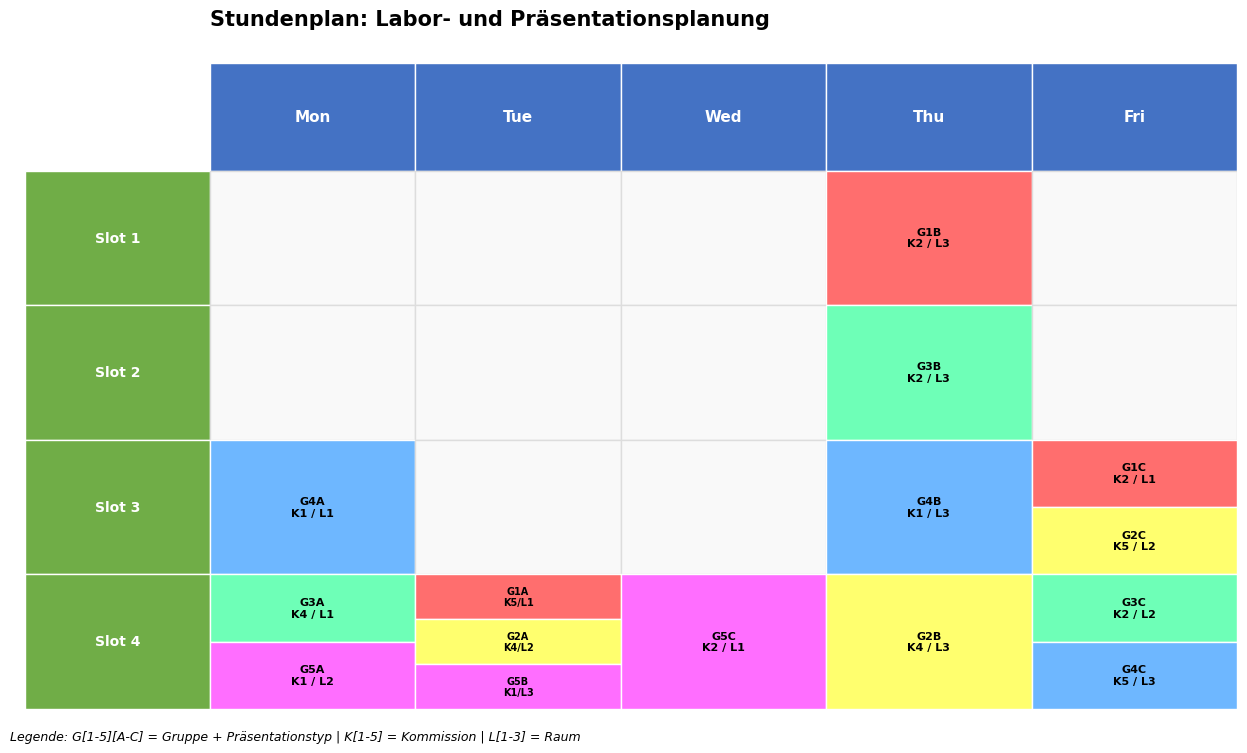

In [397]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.colors import hsv_to_rgb

# Bevorzugt OR-Tools-Loesung, fallback auf python-constraint-Loesung
candidate_solution = None
if "solution_ortools" in globals() and solution_ortools is not None:
    candidate_solution = solution_ortools
elif "solution" in globals() and solution is not None:
    candidate_solution = solution

if candidate_solution is None:
    print("Keine Lösung vorhanden!")
else:
    days_ordered = ["Mon", "Tue", "Wed", "Thu", "Fri"]
    slots_ordered = sorted(config["timeslots"], key=lambda x: int(x))

    def lighten(color, amount=0.2):
        rgb = np.array(color[:3], dtype=float)
        return np.clip(rgb + amount, 0.0, 1.0).tolist() + [1.0]

    def palette_distinct(n):
        # Gleichverteilte, kraeftige Farben im HSV-Raum
        hsv = np.stack([
            np.linspace(0, 1, n, endpoint=False),
            np.full(n, 0.8),
            np.full(n, 0.9),
        ], axis=1)
        rgb = hsv_to_rgb(hsv)
        return rgb

    # Farben pro Gruppe (klar unterscheidbar, robust bei variabler Gruppenzahl)
    groups_in_solution = sorted(set(group for group, _ in candidate_solution.keys()))
    group_count = len(groups_in_solution)
    base_colors = palette_distinct(group_count)
    color_map = {group: base_colors[i] for i, group in enumerate(groups_in_solution)}

    # Grid vorbereiten: (slot, day) -> list of entries
    schedule_cells = {(slot, day): [] for slot in slots_ordered for day in days_ordered}
    for (group, topic), (day, slot, commission, room) in candidate_solution.items():
        schedule_cells[(slot, day)].append({
            "group": group,
            "topic": topic,
            "commission": commission,
            "room": room,
        })

    # Plot-Layout
    n_rows = len(slots_ordered)
    n_cols = len(days_ordered)
    header_h = 1.0
    max_entries = max((len(v) for v in schedule_cells.values()), default=1)
    cell_w = 1.0
    cell_h = 1.0 + 0.25 * max(0, max_entries - 2)
    fig_w = 2.5 + n_cols * 2.2
    fig_h = 1.8 + n_rows * (1.2 + 0.35 * max(0, max_entries - 2))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_xlim(-0.9, n_cols)
    ax.set_ylim(0, n_rows * cell_h + header_h)
    ax.invert_yaxis()
    ax.axis("off")

    # Header: Tage
    for j, day in enumerate(days_ordered):
        ax.add_patch(Rectangle((j, 0), cell_w, header_h, facecolor="#4472C4", edgecolor="white"))
        ax.text(j + 0.5, header_h / 2, day, ha="center", va="center", color="white", fontsize=11, weight="bold")

    # Row labels: Slots
    for i, slot in enumerate(slots_ordered):
        y0 = header_h + i * cell_h
        ax.add_patch(Rectangle((-0.9, y0), 0.9, cell_h, facecolor="#70AD47", edgecolor="white"))
        ax.text(-0.45, y0 + cell_h / 2, f"Slot {slot}", ha="center", va="center", color="white", fontsize=10, weight="bold")

    # Zellen zeichnen
    for i, slot in enumerate(slots_ordered):
        for j, day in enumerate(days_ordered):
            entries = schedule_cells[(slot, day)]
            x0 = j
            y0 = header_h + i * cell_h

            if len(entries) == 0:
                ax.add_patch(Rectangle((x0, y0), cell_w, cell_h, facecolor="#f9f9f9", edgecolor="#dddddd"))
                continue

            entries_sorted = sorted(entries, key=lambda e: (e["group"], e["topic"]))
            band_h = cell_h / len(entries_sorted)

            for k, entry in enumerate(entries_sorted):
                band_y = y0 + k * band_h
                color = lighten(color_map[entry["group"]], amount=0.25)
                ax.add_patch(Rectangle((x0, band_y), cell_w, band_h, facecolor=color, edgecolor="white"))

                if band_h < 0.35:
                    lines = [f"{entry['group']}{entry['topic']} {entry['commission']}/{entry['room']}"]
                    font_size = 6
                elif band_h < 0.5:
                    lines = [f"{entry['group']}{entry['topic']}", f"{entry['commission']}/{entry['room']}"]
                    font_size = 7
                else:
                    lines = [f"{entry['group']}{entry['topic']}", f"{entry['commission']} / {entry['room']}"]
                    font_size = 8

                ax.text(
                    x0 + 0.5,
                    band_y + band_h / 2,
                    "\n".join(lines),
                    ha="center",
                    va="center",
                    fontsize=font_size,
                    weight="bold",
                )

    ax.text(0, -0.35, "Stundenplan: Labor- und Präsentationsplanung", fontsize=15, weight="bold")
    fig.text(0.08, 0.02, "Legende: G[1-5][A-C] = Gruppe + Präsentationstyp | K[1-5] = Kommission | L[1-3] = Raum", fontsize=9, style="italic")

    plt.tight_layout(rect=[0.08, 0.04, 1, 0.95])
    plt.show()

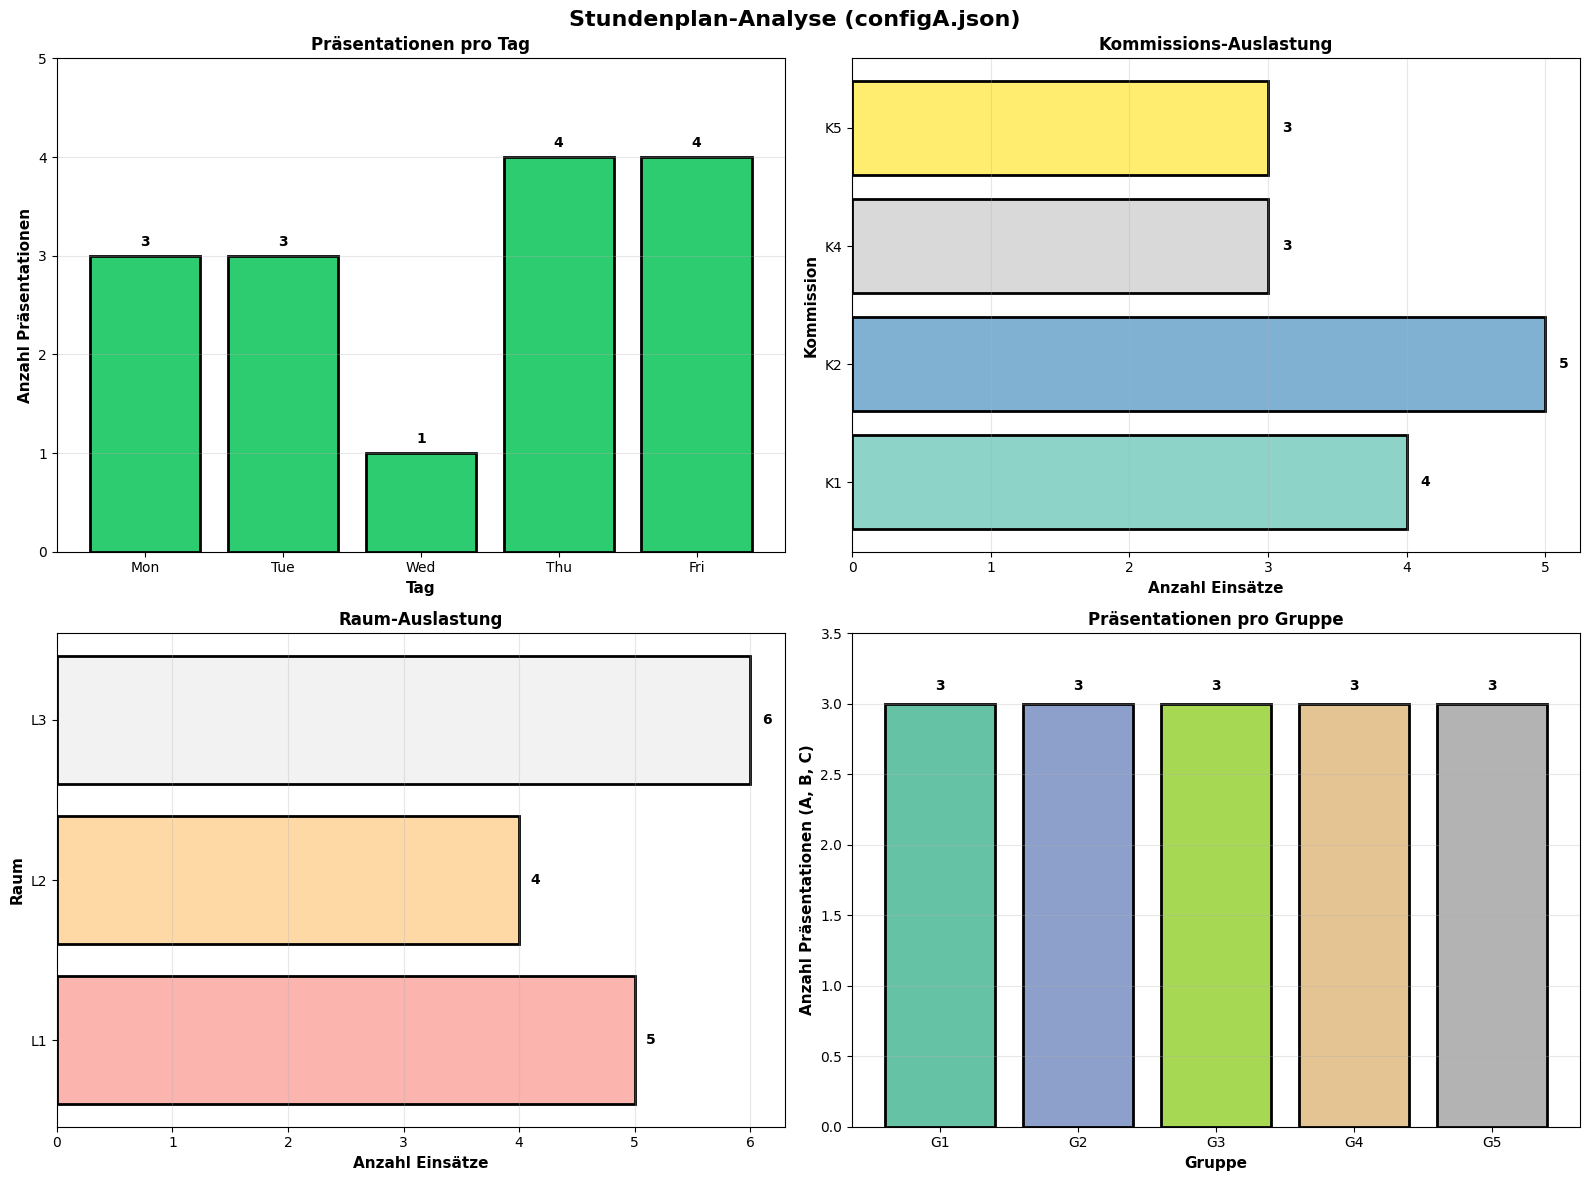

In [398]:
# ============ Grafische Visualisierungen ============
if candidate_solution is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Stundenplan-Analyse ({config_file})", fontsize=16, fontweight='bold')
    
    # --- Subplot 1: Anzahl Präsentationen pro Tag ---
    ax = axes[0, 0]
    presentations_per_day = defaultdict(int)
    for (_, _), (day, _, _, _) in candidate_solution.items():
        presentations_per_day[day] += 1
    
    days_ordered = ["Mon", "Tue", "Wed", "Thu", "Fri"]
    day_counts = [presentations_per_day.get(d, 0) for d in days_ordered]
    colors_days = ['#2ecc71' if c > 0 else '#ecf0f1' for c in day_counts]
    
    ax.bar(days_ordered, day_counts, color=colors_days, edgecolor='black', linewidth=2)
    ax.set_ylabel("Anzahl Präsentationen", fontsize=11, fontweight='bold')
    ax.set_xlabel("Tag", fontsize=11, fontweight='bold')
    ax.set_title("Präsentationen pro Tag", fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(day_counts) + 1)
    for i, v in enumerate(day_counts):
        ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # --- Subplot 2: Auslastung pro Kommission ---
    ax = axes[0, 1]
    comm_count = {}
    for (_, _), (_, _, comm, _) in candidate_solution.items():
        comm_count[comm] = comm_count.get(comm, 0) + 1
    
    comms_sorted = sorted(comm_count.keys())
    comm_values = [comm_count[c] for c in comms_sorted]
    colors_comm = plt.cm.Set3(np.linspace(0, 1, len(comms_sorted)))
    
    ax.barh(comms_sorted, comm_values, color=colors_comm, edgecolor='black', linewidth=2)
    ax.set_xlabel("Anzahl Einsätze", fontsize=11, fontweight='bold')
    ax.set_ylabel("Kommission", fontsize=11, fontweight='bold')
    ax.set_title("Kommissions-Auslastung", fontsize=12, fontweight='bold')
    for i, v in enumerate(comm_values):
        ax.text(v + 0.1, i, str(v), va='center', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # --- Subplot 3: Auslastung pro Raum ---
    ax = axes[1, 0]
    room_count = {}
    for (_, _), (_, _, _, room) in candidate_solution.items():
        room_count[room] = room_count.get(room, 0) + 1
    
    rooms_sorted = sorted(room_count.keys())
    room_values = [room_count[r] for r in rooms_sorted]
    colors_room = plt.cm.Pastel1(np.linspace(0, 1, len(rooms_sorted)))
    
    ax.barh(rooms_sorted, room_values, color=colors_room, edgecolor='black', linewidth=2)
    ax.set_xlabel("Anzahl Einsätze", fontsize=11, fontweight='bold')
    ax.set_ylabel("Raum", fontsize=11, fontweight='bold')
    ax.set_title("Raum-Auslastung", fontsize=12, fontweight='bold')
    for i, v in enumerate(room_values):
        ax.text(v + 0.1, i, str(v), va='center', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # --- Subplot 4: Präsentationen pro Gruppe ---
    ax = axes[1, 1]
    group_count = {}
    for (group, topic), _ in candidate_solution.items():
        group_count[group] = group_count.get(group, 0) + 1
    
    groups_sorted = sorted(group_count.keys())
    group_values = [group_count[g] for g in groups_sorted]
    colors_group = plt.cm.Set2(np.linspace(0, 1, len(groups_sorted)))
    
    ax.bar(groups_sorted, group_values, color=colors_group, edgecolor='black', linewidth=2)
    ax.set_ylabel("Anzahl Präsentationen (A, B, C)", fontsize=11, fontweight='bold')
    ax.set_xlabel("Gruppe", fontsize=11, fontweight='bold')
    ax.set_title("Präsentationen pro Gruppe", fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(group_values) + 0.5)
    for i, v in enumerate(group_values):
        ax.text(i, v + 0.1, str(int(v)), ha='center', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Unmöglichkeit von Config C

Konfiguration C besitzt kein Modell, dass alle Constraints erfüllt. Dies lässt sich beweisen anhand der folgenden Gegebenheiten zeigen:
1. Alle Präsentationen müssen in der Reihenfolge A -> B -> C gehalten werden (Constraint)
2. Eine Gruppe kann nur eine Präsentation pro Tag halten (Constraint)
3. Eine Kommission kann nicht zwei Vorträge parallel betreuen (Constraint)
4. Kommission "K1" ist die einzige, die Präsentation B betreuen kann
5. Kommission "K3" ist die einzige, die Präsentation C betreuen kann
6. K3 ist am Freitag nicht verfügbar

Aus (3) und (4) ergibt sich, dass es gibt eine Gruppe `G` gibt, die ihre B-Präsentation im 9. Verfügbarkeits-Slot von Kommission `K1` halten muss. Dieser 9. Slot ist Slot 2 am Donnerstag. Aus (1) und (2) folgt, dass diese Gruppe `G` ihre C-Präsentation am Tag darauf halten muss, also am Freitag. Aus (5) und (6) folgt, dass es am Freitag keinen Slot mehr geben kann, an dem `G` präsentieren kann.

Dadurch ist bewiesen, dass dieser Datensatz keine Lösung besitzt.

## Zusammenfassung: Begründung der Gesamtvorgehensweise

### Methodischer Weg

| Schritt | Werkzeug | Begründung | Konfiguration |
|---------|----------|-----------|----------------|
| **1. Modellierung** | Constraint Satisfaction Problem | Zuordnungsprobleme erfordern kombinatorische Suche mit strikten Restriktionen | 9 harte Constraints, Domains aus JSON |
| **2. Prototyp** | python-constraint | Einfache Feasibility-Analyse, schnelle Implementierung | Backtracking mit Forward Checking |
| **3. Optimierung** | Google OR-Tools CP-SAT | Solver für Feasibility + Optimierung, native Soft Objectives | Gewichtetes Ziel mit 2:1 Gewichtung |
| **4. Validierung** | Custom Validator | Unabhängige Verifikation, Transparenz, Qualitätsmetriken | 9 Constraints + Soft-Metriken |
| **5. Evaluation** | Mehrfach-Tests (A,B,C) | Machbarkeitsanalyse, Qualitätsvergleich, Edge-Cases (C: unlösbar) | Ohne JSON-Änderungen |

### Konfigurationen

**Hard Constraints:**
- Aus Aufgabenbeschreibung direkt ableitbar (Komplementbeschränkungen, Raumzuordnungen, Verfügbarkeiten)

**Soft Constraints:**
- Gewichtung 2:1 (Kommission:Raum): Kommission-Koordination ist teurer
- Ziel: Interne Leerlaufzeiten minimieren

**Solver-Parameter:**
- Status OPTIMAL/FEASIBLE: Realistisch; OPTIMAL in unter 20s oft erreichbar für diese Problemgröße

**Validator-Design:**
- Vollständig unabhängig von CSP-Löser $\rightarrow$ Vertrauenswürdigkeit
- Soft-Metriken nach exakt gleicher Definition wie Optimierungsziel $\rightarrow$ Konsistenzcheck

### Ergebnis-Interpretation
- **Erfolg (A, B):** Zeigt CSP-Modell funktioniert. Soft Metrics geben Qualitätszahl
- **Misserfolg (C):** Beweis, dass das Problem wirklich unlösbar ist
- **Qualitätsvergleich (A vs. B):** Unterschiedliche Instanzgröße $\rightarrow$ unterschiedliche Leerlaufmuster, aber ähnliches Constraint-Einhalten